# Projeto Parte 1

### Aluno: Denise Almeida de Souza

# Instalação de Pacotes

In [14]:
install.packages(c("readxl", "skimr", "ggplot2" ), dep=TRUE) 
library(readxl)
library(knitr)
library(ggplot2)
library(skimr)



Os pacotes binários baixados estão em
	/var/folders/wj/_vm5m8g909gbgb5kst1b84900000gn/T//RtmpJP4H8M/downloaded_packages


# Leitura e tratamento dos dados

In [15]:
url0 <- 'https://raw.githubusercontent.com/filipezabala/pucrs-tecnologo-bd/main/dados/Anexo_Projeto_fifa_world_national_teams_versa%CC%83o_oficial%2020241.csv'
fifa <- read.csv(url0, sep = ';', encoding = 'latin1')
str(fifa)

'data.frame':	718 obs. of  30 variables:
 $ id                           : int  158023 153079 211110 201399 226226 199667 212616 216816 183892 231478 ...
 $ name                         : chr  "Messi" "Aguero" "Dybala" "Icardi" ...
 $ full_name                    : chr  "Lionel Andrés Messi Cuccittini" "Sergio Leonel Agüero del Castillo" "Paulo Bruno Exequiel Dybala" "Mauro Emanuel Icardi Rivero" ...
 $ overall_rating               : int  94 89 89 87 82 77 77 78 79 79 ...
 $ value_euro                   : int  110500000 64500000 89000000 64500000 30000000 8500000 12000000 15000000 8500000 18000000 ...
 $ wage_euro                    : int  565000 300000 205000 130000 83000 28000 27000 53000 19000 54000 ...
 $ nationality                  : chr  "Argentina" "Argentina" "Argentina" "Argentina" ...
 $ national_team                : chr  "Argentina" "Argentina" "Argentina" "Argentina" ...
 $ club_team                    : chr  "FC Barcelona" "Manchester City" "Juventus" "Inter" ...
 $ age 

### Avaliando a descrição das variáveis

In [16]:
descriptions <- read_excel("../data/raw/data_dictionary.xlsx")
View(descriptions)

Variable,Descricao
<chr>,<chr>
id,Número de identificacao
name,Nome resumido do jogador
full_name,Nome completo do jogador
overall_rating,Escore de avaliacao geral de 0-100
value_euro,Valor do jogador no mercado (Euros)
wage_euro,Salario em Euros
nationality,nacionalidade
national_team,Selecao na qual atua
club_team,Clube no qual atua


In [17]:
names(fifa)

[1] "id"                            "name"                         
 [3] "full_name"                     "overall_rating"               
 [5] "value_euro"                    "wage_euro"                    
 [7] "nationality"                   "national_team"                
 [9] "club_team"                     "age"                          
[11] "height_cm"                     "weight_kgs"                   
[13] "international_reputation.1.5." "weak_foot.1.5."               
[15] "skill_moves.1.5."              "club_rating"                  
[17] "Goleiro"                       "Zagueiro"                     
[19] "Meio"                          "Atacante"                     
[21] "crossing"                      "finishing"                    
[23] "heading_accuracy"              "short_passing"                
[25] "dribbling"                     "jumping"                      
[27] "strength"                      "long_shots"                   
[29] "aggression"                    "GK_reflexes"

# Estatísticas Descritivas

In [18]:
fltr_num <- sapply(fifa, is.integer)
summary(fifa[,fltr_num])

       id         overall_rating    value_euro          wage_euro     
 Min.   : 20801   Min.   :58.00   Min.   :   230000   Min.   :  1000  
 1st Qu.:189831   1st Qu.:72.00   1st Qu.:  3325000   1st Qu.: 10000  
 Median :204626   Median :76.00   Median :  8000000   Median : 27000  
 Mean   :203668   Mean   :76.46   Mean   : 13897695   Mean   : 49560  
 3rd Qu.:222200   3rd Qu.:80.00   3rd Qu.: 17000000   3rd Qu.: 59000  
 Max.   :246387   Max.   :94.00   Max.   :110500000   Max.   :565000  
      age          height_cm     weight_kgs     international_reputation.1.5.
 Min.   :18.00   Min.   :152   Min.   : 59.00   Min.   :1.000                
 1st Qu.:24.00   1st Qu.:170   1st Qu.: 73.00   1st Qu.:1.000                
 Median :26.00   Median :183   Median : 77.00   Median :1.000                
 Mean   :26.57   Mean   :177   Mean   : 77.67   Mean   :1.673                
 3rd Qu.:29.00   3rd Qu.:188   3rd Qu.: 82.00   3rd Qu.:2.000                
 Max.   :37.00   Max.   :203   Max.

In [19]:
# skim(fifa)

# Exercícios do projeto:


### 1) Encontrando exemplos para cada tipo de variável:

#### Qualitativa nominal: full_name: Nome completo do jogador
#### Qualitativa ordinal: overall_rating : Escore de avaliacao geral de 0-100
#### Quantitativa discreta: age: Idade
#### Quantitativa contínua: weight_kgs: Peso

### 2) Tabelas de frequência para duas variáveis qualitativas; 

### Explorando visualizações de tabelas de frequência:

#### Tabela de frequência do clube:

In [20]:
freq_table <- as.data.frame(table(fifa$club_team))
freq_table <- freq_table[order(-freq_table$Freq), ]
freq_table$relativa <- round(100 * freq_table$Freq / sum(freq_table$Freq), 2) 
kable(freq_table, col.names = c("País", "Frequência Absoluta", "Frequência Relativa %"), caption = "Tabela de Frequência Clubes")



Table: Tabela de Frequência Clubes

|    |País                          | Frequência Absoluta| Frequência Relativa %|
|:---|:-----------------------------|-------------------:|---------------------:|
|68  |FC Bayern Munchen             |                  14|                  1.95|
|103 |Juventus                      |                  14|                  1.95|
|207 |Tottenham Hotspur             |                  14|                  1.95|
|45  |Celtic                        |                  12|                  1.67|
|123 |Manchester United             |                  12|                  1.67|
|21  |Atletico Madrid               |                  11|                  1.53|
|67  |FC Barcelona                  |                  11|                  1.53|
|167 |Real Madrid                   |                  11|                  1.53|
|48  |Chelsea                       |                  10|                  1.39|
|122 |Manchester City               |                  10|  

#### Tabela de frequência sobre a nacionalidade dos jogadores:

In [21]:
freq_table <- as.data.frame(table(fifa$nationality))
freq_table <- freq_table[order(-freq_table$Freq), ]
freq_table$Relativa <- round(100 * freq_table$Freq / sum(freq_table$Freq), 2) 
kable(freq_table, col.names = c("País", "Frequência Absoluta", "Frequência Relativa %"), caption = "Tabela de Frequência Nacionalidade")




Table: Tabela de Frequência Nacionalidade

|   |País                | Frequência Absoluta| Frequência Relativa %|
|:--|:-------------------|-------------------:|---------------------:|
|5  |Brazil              |                  23|                  3.20|
|12 |Denmark             |                  23|                  3.20|
|15 |England             |                  23|                  3.20|
|17 |France              |                  23|                  3.20|
|18 |Germany             |                  23|                  3.20|
|25 |Netherlands         |                  23|                  3.20|
|35 |Scotland            |                  23|                  3.20|
|38 |Spain               |                  23|                  3.20|
|42 |United States       |                  23|                  3.20|
|22 |Italy               |                  22|                  3.06|
|27 |Norway              |                  22|                  3.06|
|19 |Greece              |      

### 3) Uma tabela com medidas de posição e variabilidade para ao menos 5 variáveis a serem escolhidas; 

In [22]:
# Função para moda
Mode <- function(x) {
  ux <- unique(x)
  ux[which.max(tabulate(match(x, ux)))]
}

# Variáveis escolhidas
vars <- c("age", "wage_euro", "overall_rating", "international_reputation.1.5.", "weight_kgs")

# Tabela resumo
tabela_resumo <- data.frame(
  Variavel = vars,
  Media = round(sapply(fifa[vars], mean, na.rm = TRUE), 2),
  Mediana = round(sapply(fifa[vars], median, na.rm = TRUE),2),
  Moda = round(sapply(fifa[vars], Mode),2),
  Desvio_Padrao = round(sapply(fifa[vars], sd, na.rm = TRUE),2),
  Variancia = round(sapply(fifa[vars], var, na.rm = TRUE),2),
  Minimo = round(sapply(fifa[vars], min, na.rm = TRUE),2),
  Maximo = round(sapply(fifa[vars], max, na.rm = TRUE),2),
  Amplitude = round(sapply(fifa[vars], function(x) max(x, na.rm = TRUE) - min(x, na.rm = TRUE)),2)
)

View(tabela_resumo)


,Variavel,Media,Mediana,Moda,Desvio_Padrao,Variancia,Minimo,Maximo,Amplitude
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
age,age,26.57,26,26,3.59,1.288000e+01,18,37,19
wage_euro,wage_euro,49559.89,27000,1000,65224.91,4.254289e+09,1000,565000,564000
overall_rating,overall_rating,76.46,76,74,6.02,3.622000e+01,58,94,36
international_reputation.1.5.,international_reputation.1.5.,1.67,1,1,0.89,8.000000e-01,1,5,4
weight_kgs,weight_kgs,77.67,77,70,7.30,5.327000e+01,59,100,41


### 4) Ao menos dois gráficos criativos para ajudar na visualização de resultados, conforme orientações dadas em aula pelo professor Hélio; 


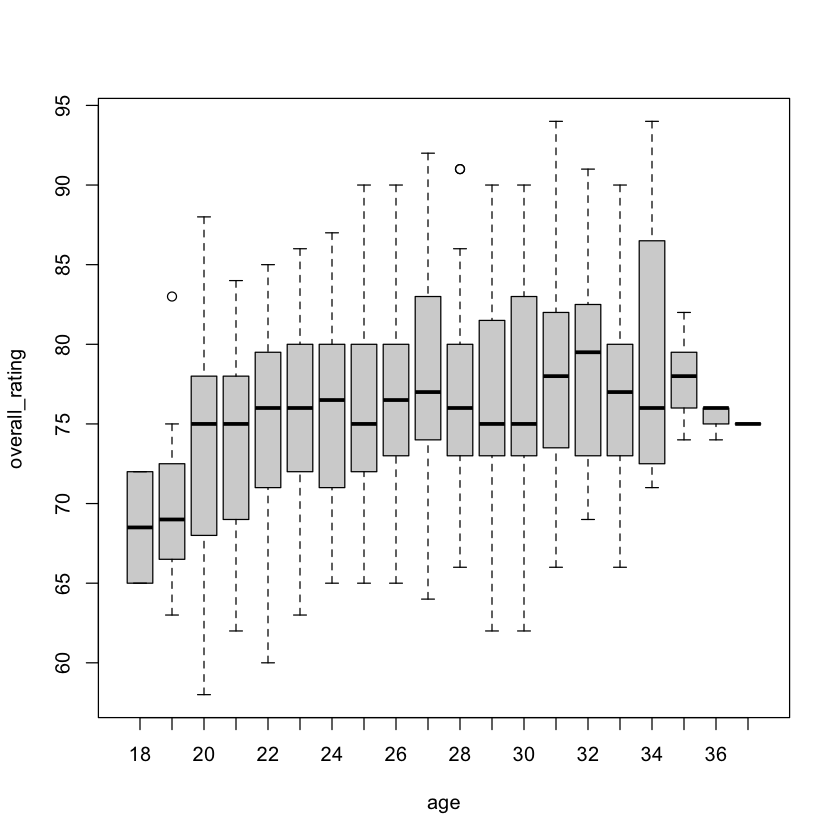

In [23]:
boxplot(overall_rating ~ age , data = fifa)

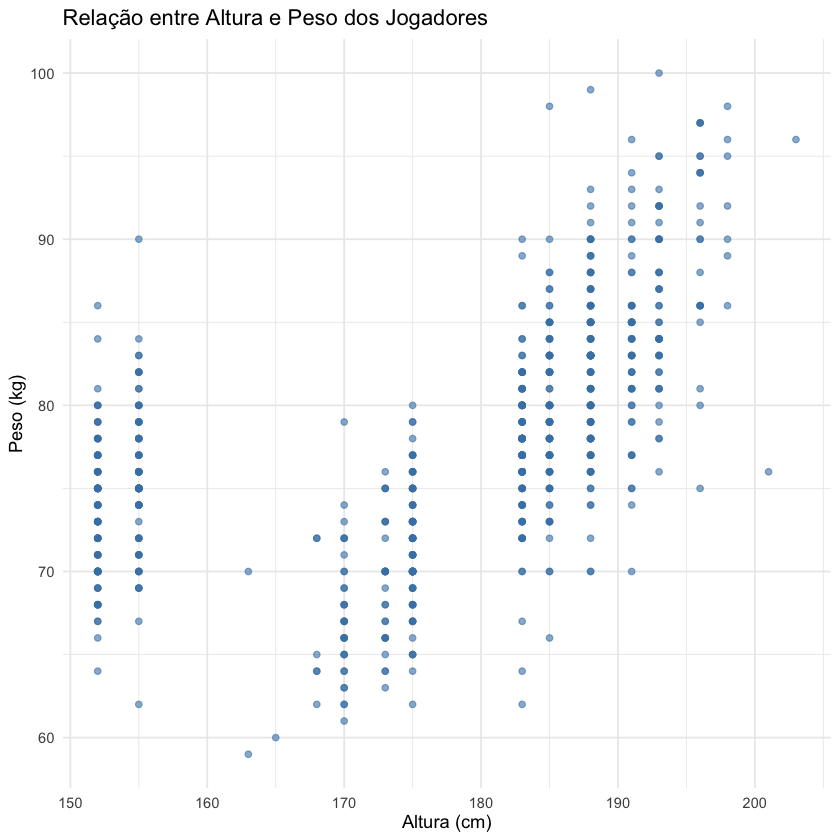

In [24]:
ggplot(fifa, aes(x = height_cm, y = weight_kgs)) +
  geom_point(alpha = 0.6, color = "steelblue") +
  labs(
    title = "Relação entre Altura e Peso dos Jogadores",
    x = "Altura (cm)",
    y = "Peso (kg)"
  ) +
  theme_minimal()

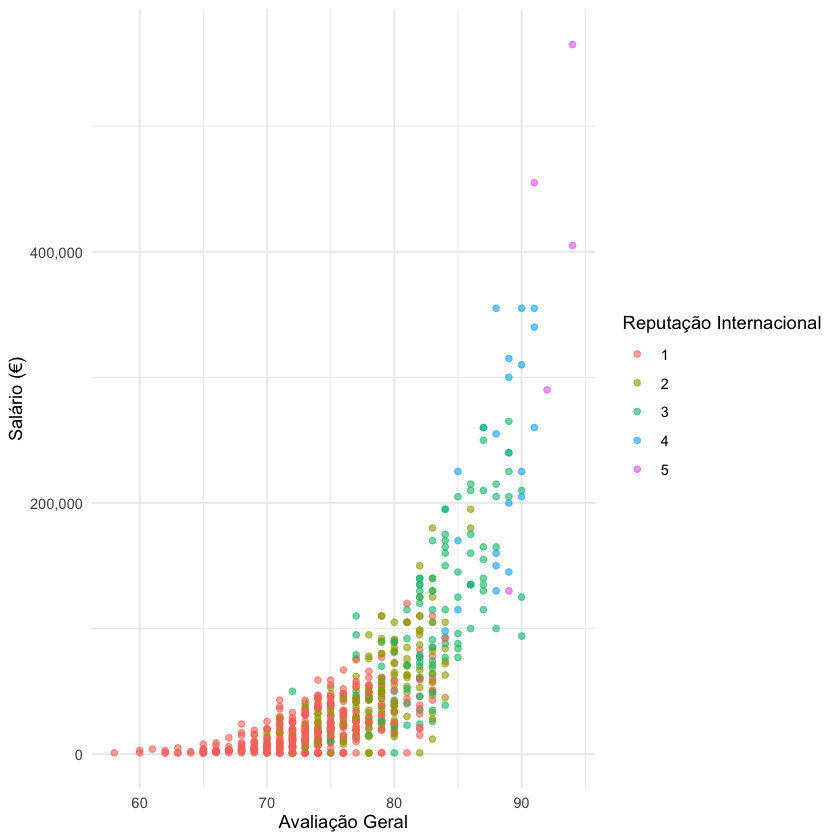

In [25]:
ggplot(fifa, aes(x = overall_rating, y = wage_euro,
                  color = factor(international_reputation.1.5.))) +
  geom_point(alpha = 0.6) +
  scale_y_continuous(labels = scales::comma) +
  labs(
       x = "Avaliação Geral",
       y = "Salário (€)",
       color = "Reputação Internacional", size = "Finalizações") +
  theme_minimal()


### 5. Um histograma ou gráfico de barra para verificação de adequabilidade do modelo probabilístico para a variável escolhida, devidamente interpretado. 

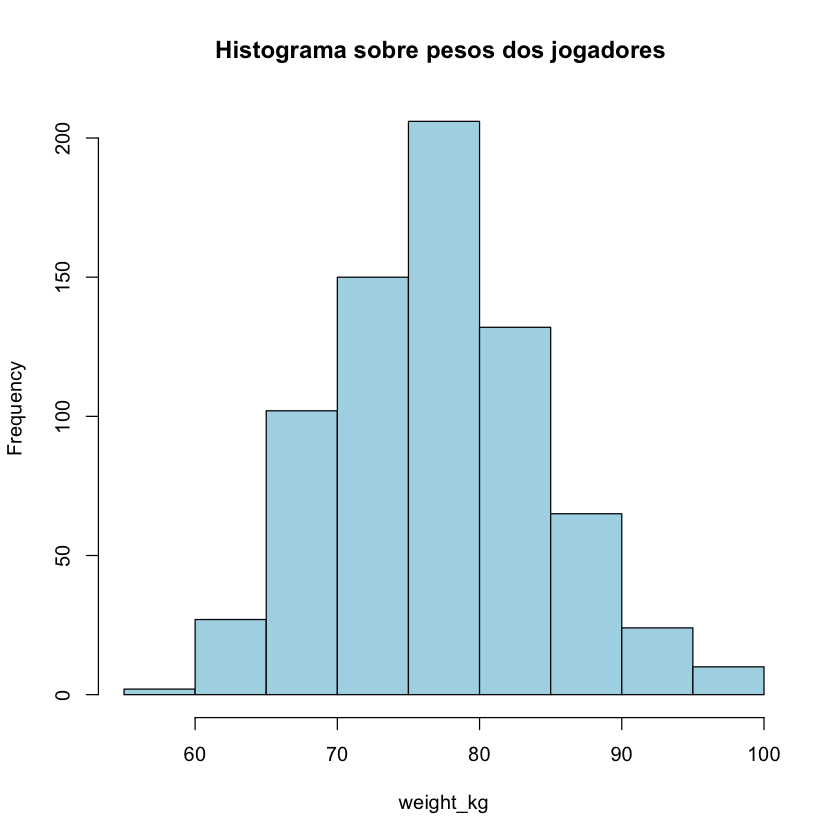

In [64]:
hist(fifa$weight_kgs, main="Histograma sobre pesos dos jogadores ", xlab="weight_kg", col="lightblue", border="black")

#### Função acumulada empírica:

Identificando  qual a proporção de observações do conjunto de dados original

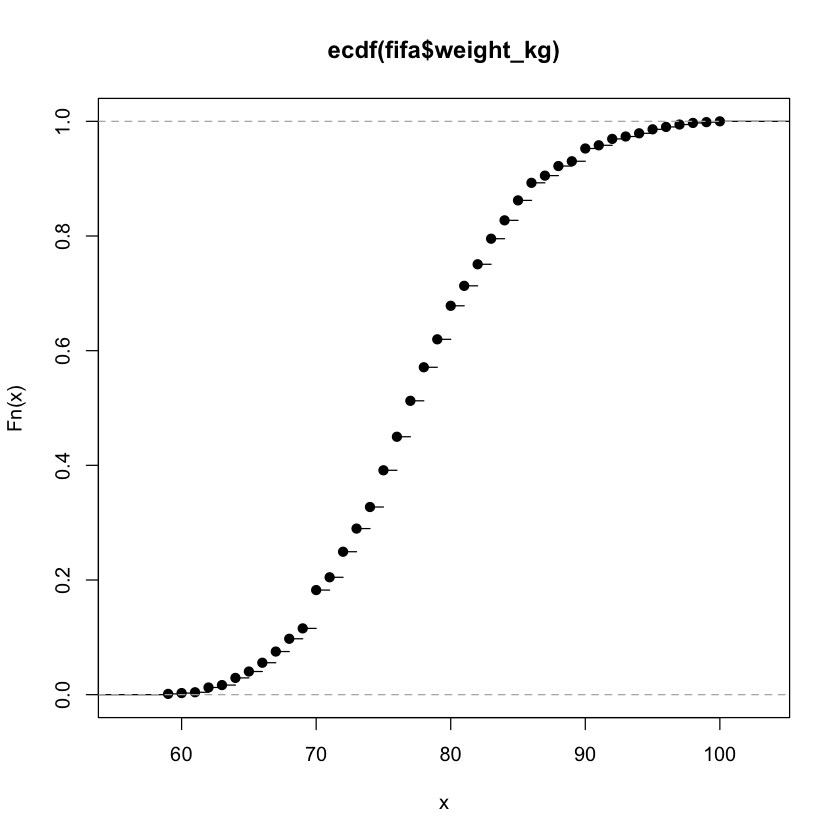

In [57]:
cs <- ecdf(fifa$weight_kg)
plot(cs) 


#### Função acumulada teórica:

Aplicando a curva de distribuição normal ajustando os dados com base na média e no desvio padrão.

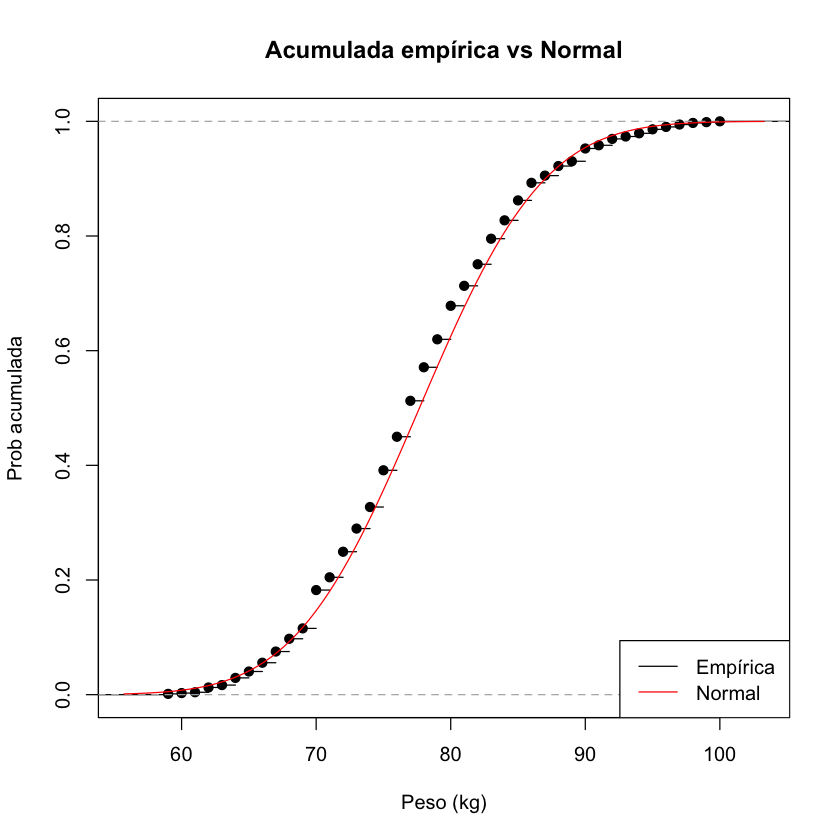

In [63]:
plot(cs, main="Acumulada empírica vs Normal", xlab="Peso (kg)", ylab="Prob acumulada")
curve(pnorm(x, mean=media, sd=desvio), add=TRUE, col="red")
legend("bottomright", legend=c("Empírica", "Normal"), col=c("black","red"), lty=1)


A aproximação da distribuição empírica e normal indica que a distribuição normal é razoavelmente adequada para descrever os dados dos pesos dos jogadores.